In [ ]:
import numpy as np
import pandas as pd
dict_data = {
    "Age":[23,28,37,np.nan,49,26,30,38,104,45,25,np.nan,29,34,np.nan],
    "Experience":[-2,7,16,8,np.nan,28,5,-16,np.nan,8,89,7,12,18,-6],
    "Salary":[800000,1200000,600000,np.nan,10000000,800000,2400000,np.nan,1200000,2400000,np.nan,1600000,1000000,700000,400000]
}
data = pd.DataFrame(dict_data)
print(data)

      Age  Experience      Salary
0    23.0        -2.0    800000.0
1    28.0         7.0   1200000.0
2    37.0        16.0    600000.0
3     NaN         8.0         NaN
4    49.0         NaN  10000000.0
5    26.0        28.0    800000.0
6    30.0         5.0   2400000.0
7    38.0       -16.0         NaN
8   104.0         NaN   1200000.0
9    45.0         8.0   2400000.0
10   25.0        89.0         NaN
11    NaN         7.0   1600000.0
12   29.0        12.0   1000000.0
13   34.0        18.0    700000.0
14    NaN        -6.0    400000.0


In [ ]:
data['Experience'] = data['Experience'].abs()

In [ ]:
data['Experience'].fillna(data['Experience'].mean(),inplace=True)
data['Age'].fillna(data['Age'].mean(),inplace=True)
data['Salary'].fillna(data['Salary'].mean(),inplace=True)

/tmp/ipython-input-1082455683.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Experience'].fillna(data['Experience'].mean(),inplace=True)
/tmp/ipython-input-1082455683.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [ ]:
print(data)

      Age  Experience      Salary
0    23.0    2.000000    800000.0
1    28.0    7.000000   1200000.0
2    37.0   16.000000    600000.0
3    39.0    8.000000   1925000.0
4    49.0   17.076923  10000000.0
5    26.0   28.000000    800000.0
6    30.0    5.000000   2400000.0
7    38.0   16.000000   1925000.0
8   104.0   17.076923   1200000.0
9    45.0    8.000000   2400000.0
10   25.0   89.000000   1925000.0
11   39.0    7.000000   1600000.0
12   29.0   12.000000   1000000.0
13   34.0   18.000000    700000.0
14   39.0    6.000000    400000.0


In [ ]:
from scipy import stats
z_score = np.abs(stats.zscore(data))
outliers = data[z_score>2.5]
z_score_data = data[(z_score<3).all(axis=1)]
print("Outliers:")
print(outliers)
print("\nProcessed Data:")
print(z_score_data)

Outliers:
      Age  Experience      Salary
4    49.0   17.076923  10000000.0
8   104.0   17.076923   1200000.0
10   25.0   89.000000   1925000.0

Processed Data:
     Age  Experience     Salary
0   23.0         2.0   800000.0
1   28.0         7.0  1200000.0
2   37.0        16.0   600000.0
3   39.0         8.0  1925000.0
5   26.0        28.0   800000.0
6   30.0         5.0  2400000.0
7   38.0        16.0  1925000.0
9   45.0         8.0  2400000.0
11  39.0         7.0  1600000.0
12  29.0        12.0  1000000.0
13  34.0        18.0   700000.0
14  39.0         6.0   400000.0


In [ ]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR
outlier_mask = ((data<lower_bound) | (data>upper_bound)).any(axis=1)
data = data[~outlier_mask]
print(data)

     Age  Experience     Salary
0   23.0         2.0   800000.0
1   28.0         7.0  1200000.0
2   37.0        16.0   600000.0
3   39.0         8.0  1925000.0
5   26.0        28.0   800000.0
6   30.0         5.0  2400000.0
7   38.0        16.0  1925000.0
9   45.0         8.0  2400000.0
11  39.0         7.0  1600000.0
12  29.0        12.0  1000000.0
13  34.0        18.0   700000.0
14  39.0         6.0   400000.0


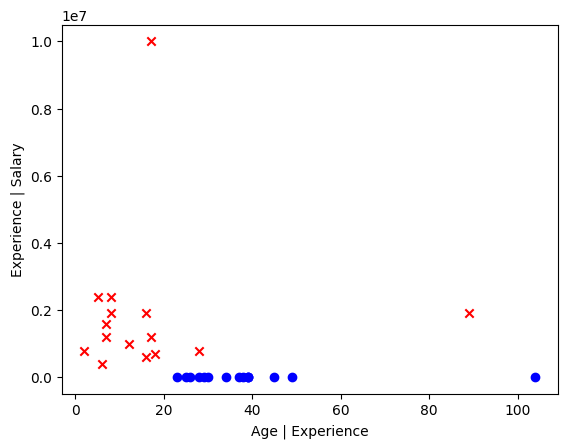

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(data['Age'],data['Experience'],c='blue',marker='o')
plt.scatter(data['Experience'],data['Salary'],c='red',marker='x')
plt.xlabel("Age | Experience")
plt.ylabel("Experience | Salary")
plt.show()


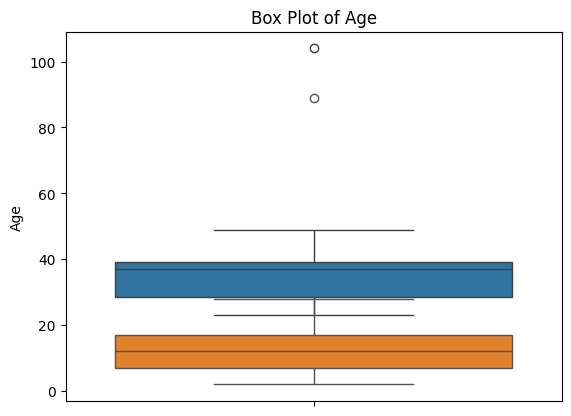

In [ ]:
import seaborn as sns
sns.boxplot(data['Age'])
sns.boxplot(data['Experience'])
plt.title("Box Plot of Age")
plt.show()

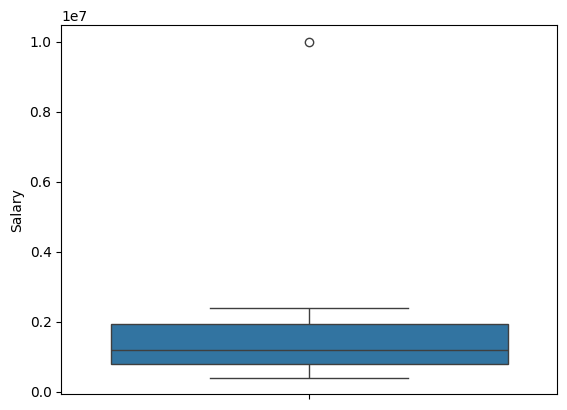

In [ ]:
sns.boxplot(data['Salary'])
plt.show()